In [1]:
from tqdm import tqdm
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import pickle
import os
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, Model, regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.text import Tokenizer

In [2]:
!pip install gdown -q

!gdown "1DpGve3p7upCLXUaxrkwhy9ZjI3LQNRf2" -O dataset_final.csv

import pandas as pd
df = pd.read_csv('dataset_final.csv')
df = df.dropna(subset=['text', 'label'])
df = df[['text', 'label']].reset_index(drop=True)

print(df['label'].value_counts())
print(df.shape)

Downloading...
From: https://drive.google.com/uc?id=1DpGve3p7upCLXUaxrkwhy9ZjI3LQNRf2
To: /content/dataset_final.csv
100% 70.8M/70.8M [00:00<00:00, 115MB/s] 
label
1    38107
0    27627
Name: count, dtype: int64
(65734, 2)


In [3]:
X = df['text'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 52587 | Test: 13147


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
MAX_LEN    = 250
VOCAB_SIZE = 20000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, truncating='post', padding='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, truncating='post', padding='post')

print(f"X_train shape: {X_train_pad.shape}")
print(f"X_test shape:  {X_test_pad.shape}")

os.makedirs('/content/drive/MyDrive/fake-news-detection/tokenizer', exist_ok=True)
with open('/content/drive/MyDrive/fake-news-detection/tokenizer/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Tokenizer saved!")

X_train shape: (52587, 250)
X_test shape:  (13147, 250)
Tokenizer saved!


In [6]:
class AttentionLayer(layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name='attention_weight',
            shape=(input_shape[-1], 1),
            initializer='glorot_uniform',
            regularizer=regularizers.l2(1e-4),
            trainable=True
        )
        self.b = self.add_weight(
            name='attention_bias',
            shape=(input_shape[1], 1),
            initializer='zeros',
            trainable=True
        )
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        e = tf.nn.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        a = tf.nn.softmax(e, axis=1)
        output = x * a
        return tf.reduce_sum(output, axis=1)

    def get_config(self):
        return super(AttentionLayer, self).get_config()

In [7]:
EMBED_DIM = 128
L2        = 1e-4

inputs = layers.Input(shape=(MAX_LEN,), name='input_layer')

x = layers.Embedding(
    VOCAB_SIZE, EMBED_DIM,
    embeddings_regularizer=regularizers.l2(L2),
    name='embedding'
)(inputs)
x = layers.SpatialDropout1D(0.3, name='spatial_dropout')(x)

x = layers.GRU(
    96,
    return_sequences=True,
    dropout=0.2,
    kernel_regularizer=regularizers.l2(L2),
    recurrent_regularizer=regularizers.l2(L2),
    name='gru'
)(x)

x = AttentionLayer(name='attention')(x)

x = layers.Dense(
    48, activation='relu',
    kernel_regularizer=regularizers.l2(L2),
    name='dense'
)(x)
x = layers.Dropout(0.4, name='dropout')(x)

outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

model = Model(inputs, outputs, name='GRU_Attention')
model.summary()

Model: "GRU_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 250, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 250, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 250, 96)        │        65,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (AttentionLayer)      │ (None, 96)             │           346 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 48)             │         4,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            49 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,630,139 (10.03 MB)

 Trainable params: 2,630,139 (10.03 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
EPOCHS        = 30
BATCH_SIZE    = 64
LEARNING_RATE = 3e-4

ES_PATIENCE  = 5
ES_MIN_DELTA = 1e-4

LR_PATIENCE = 3
LR_FACTOR   = 0.5
LR_MIN      = 1e-6

CLIP_NORM = 1.0

best_val_loss     = np.inf
patience_counter  = 0
lr_patience_counter = 0
current_lr        = LEARNING_RATE

optimizer = tf.keras.optimizers.Adam(learning_rate=current_lr, clipnorm=CLIP_NORM)
loss_fn   = tf.keras.losses.BinaryCrossentropy()

log_dir = '/content/drive/MyDrive/fake-news-detection/logs/gru'
os.makedirs(log_dir, exist_ok=True)
writer = tf.summary.create_file_writer(log_dir)

checkpoint_path = '/content/drive/MyDrive/fake-news-detection/models/best_model_gru.keras'
os.makedirs('/content/drive/MyDrive/fake-news-detection/models', exist_ok=True)

print("Training config ready!")

Training config ready!


In [9]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train_pad, y_train)).shuffle(10000).batch(BATCH_SIZE)
test_dataset  = tf.data.Dataset.from_tensor_slices(
    (X_test_pad, y_test)).batch(BATCH_SIZE)

train_acc_metric = tf.keras.metrics.BinaryAccuracy()
val_acc_metric   = tf.keras.metrics.BinaryAccuracy()

label_smoothing = tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1)

history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS} | LR: {current_lr:.6f}")
    train_acc_metric.reset_state()
    val_acc_metric.reset_state()
    epoch_loss = []

    train_bar = tqdm(train_dataset, desc='  Train', unit='batch', leave=False)
    for x_batch, y_batch in train_bar:
        with tf.GradientTape() as tape:
            preds = model(x_batch, training=True)
            loss  = label_smoothing(y_batch, preds)
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        train_acc_metric.update_state(y_batch, preds)
        epoch_loss.append(loss.numpy())
        train_bar.set_postfix(loss=f"{loss.numpy():.4f}", acc=f"{train_acc_metric.result().numpy():.4f}")

    val_bar       = tqdm(test_dataset, desc='  Val  ', unit='batch', leave=False)
    val_loss_list = []
    for x_batch, y_batch in val_bar:
        val_preds = model(x_batch, training=False)
        val_loss  = loss_fn(y_batch, val_preds)
        val_acc_metric.update_state(y_batch, val_preds)
        val_loss_list.append(val_loss.numpy())
        val_bar.set_postfix(val_loss=f"{val_loss.numpy():.4f}", val_acc=f"{val_acc_metric.result().numpy():.4f}")

    avg_loss     = np.mean(epoch_loss)
    avg_val_loss = np.mean(val_loss_list)
    avg_acc      = train_acc_metric.result().numpy()
    avg_val_acc  = val_acc_metric.result().numpy()
    gap          = avg_acc - avg_val_acc

    history['loss'].append(avg_loss)
    history['accuracy'].append(avg_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_accuracy'].append(avg_val_acc)

    print(f"loss: {avg_loss:.4f} | acc: {avg_acc:.4f} | val_loss: {avg_val_loss:.4f} | val_acc: {avg_val_acc:.4f} | gap: {gap:.4f}")

    with writer.as_default():
        tf.summary.scalar('loss',         avg_loss,     step=epoch)
        tf.summary.scalar('accuracy',     avg_acc,      step=epoch)
        tf.summary.scalar('val_loss',     avg_val_loss, step=epoch)
        tf.summary.scalar('val_accuracy', avg_val_acc,  step=epoch)
        tf.summary.scalar('train_val_gap', gap,         step=epoch)

    if avg_val_loss < best_val_loss - ES_MIN_DELTA:
        print(f"  val_loss membaik ({best_val_loss:.4f} -> {avg_val_loss:.4f}), menyimpan model...")
        best_val_loss     = avg_val_loss
        patience_counter  = 0
        lr_patience_counter = 0
        model.save(checkpoint_path)
    else:
        patience_counter    += 1
        lr_patience_counter += 1
        print(f"  Tidak ada peningkatan. EarlyStopping: {patience_counter}/{ES_PATIENCE} | ReduceLR: {lr_patience_counter}/{LR_PATIENCE}")

    if lr_patience_counter >= LR_PATIENCE:
        new_lr = max(current_lr * LR_FACTOR, LR_MIN)
        if new_lr < current_lr:
            current_lr = new_lr
            optimizer.learning_rate.assign(current_lr)
            print(f"  LR diturunkan -> {current_lr:.6f}")
        lr_patience_counter = 0

    if patience_counter >= ES_PATIENCE:
        print(f"\nEarlyStopping. Best val_loss: {best_val_loss:.4f}")
        break

print("\nTraining selesai!")

model = tf.keras.models.load_model(
    checkpoint_path,
    custom_objects={'AttentionLayer': AttentionLayer}
)
print("Best model loaded!")


Epoch 1/30 | LR: 0.000300


loss: 0.3207 | acc: 0.9207 | val_loss: 0.1374 | val_acc: 0.9663 | gap: -0.0456
  val_loss membaik (inf -> 0.1374), menyimpan model...

Epoch 2/30 | LR: 0.000300


loss: 0.2468 | acc: 0.9778 | val_loss: 0.1084 | val_acc: 0.9735 | gap: 0.0044
  val_loss membaik (0.1374 -> 0.1084), menyimpan model...

Epoch 3/30 | LR: 0.000300


loss: 0.2358 | acc: 0.9846 | val_loss: 0.0990 | val_acc: 0.9757 | gap: 0.0090
  val_loss membaik (0.1084 -> 0.0990), menyimpan model...

Epoch 4/30 | LR: 0.000300


loss: 0.2290 | acc: 0.9880 | val_loss: 0.0979 | val_acc: 0.9773 | gap: 0.0107
  val_loss membaik (0.0990 -> 0.0979), menyimpan model...

Epoch 5/30 | LR: 0.000300


loss: 0.2254 | acc: 0.9902 | val_loss: 0.1056 | val_acc: 0.9764 | gap: 0.0137
  Tidak ada peningkatan. EarlyStopping: 1/5 | ReduceLR: 1/3

Epoch 6/30 | LR: 0.000300


loss: 0.2217 | acc: 0.9918 | val_loss: 0.0984 | val_acc: 0.9773 | gap: 0.0145
  Tidak ada peningkatan. EarlyStopping: 2/5 | ReduceLR: 2/3

Epoch 7/30 | LR: 0.000300


loss: 0.2187 | acc: 0.9933 | val_loss: 0.1066 | val_acc: 0.9764 | gap: 0.0169
  Tidak ada peningkatan. EarlyStopping: 3/5 | ReduceLR: 3/3
  LR diturunkan -> 0.000150

Epoch 8/30 | LR: 0.000150


loss: 0.2151 | acc: 0.9952 | val_loss: 0.1048 | val_acc: 0.9763 | gap: 0.0189
  Tidak ada peningkatan. EarlyStopping: 4/5 | ReduceLR: 1/3

Epoch 9/30 | LR: 0.000150


loss: 0.2136 | acc: 0.9962 | val_loss: 0.1095 | val_acc: 0.9756 | gap: 0.0206
  Tidak ada peningkatan. EarlyStopping: 5/5 | ReduceLR: 2/3

EarlyStopping. Best val_loss: 0.0979

Training selesai!
Best model loaded!


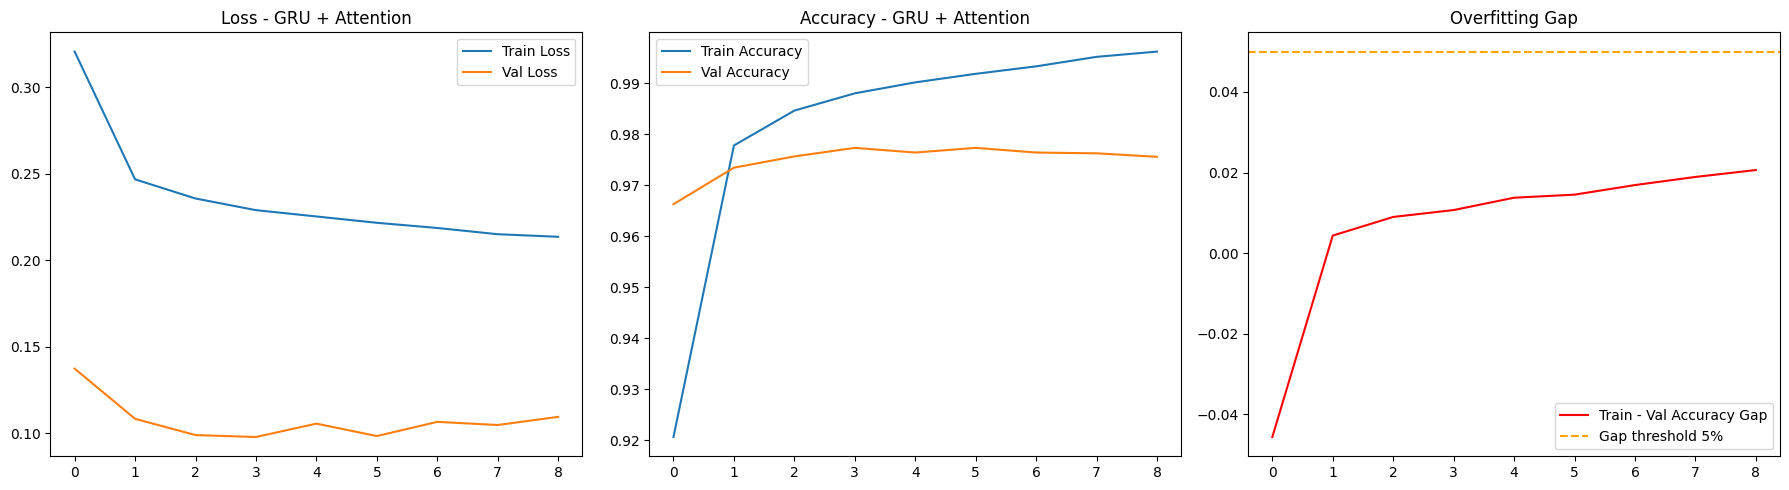

411/411 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
              precision    recall  f1-score   support

       FAKTA       0.98      0.97      0.97      5525
       HOAKS       0.98      0.99      0.98      7622

    accuracy                           0.98     13147
   macro avg       0.98      0.98      0.98     13147
weighted avg       0.98      0.98      0.98     13147



In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['loss'],     label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_title('Loss - GRU + Attention')
axes[0].legend()

axes[1].plot(history['accuracy'],     label='Train Accuracy')
axes[1].plot(history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy - GRU + Attention')
axes[1].legend()

gap_series = [a - b for a, b in zip(history['accuracy'], history['val_accuracy'])]
axes[2].plot(gap_series, color='red', label='Train - Val Accuracy Gap')
axes[2].axhline(y=0.05, color='orange', linestyle='--', label='Gap threshold 5%')
axes[2].set_title('Overfitting Gap')
axes[2].legend()

plt.tight_layout()
plt.show()

y_pred = (model.predict(X_test_pad) >= 0.5).astype(int)
print(classification_report(y_test, y_pred, target_names=['FAKTA', 'HOAKS']))

In [11]:
model.save('/content/drive/MyDrive/fake-news-detection/models/model_gru.keras')
print("Model GRU saved!")

Model GRU saved!
